In [1]:
%pylab inline
from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.filter import sigma
from pycbc.inject import InjectionSet

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [267]:
t = InjectionSet("m1_480_m2_120_z_7.hdf")
for i, inj in enumerate(t.table):
    pass
# delta_t = 0.001953125
delta_f = 0.125
f_l = 3
fh = 256

In [260]:
params = {
    'approximant': 'IMRPhenomXHM',
    'coa_phase': 0.0,
    'mass1': 3672.533,
    'mass2': 918.1332,
    'spin1z': 0.0,
    'spin2z': 0.0,
    'inclination': 1.047198,
}

In [268]:
hp_tilde, hc_tilde = get_fd_waveform(**params, delta_f=delta_f, f_lower=f_l, f_final=fh)

In [269]:
hp = hp_tilde.to_timeseries()

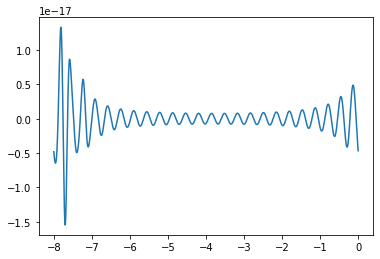

In [270]:
hp.plot()

In [271]:
pwd

'/Users/camill/projects/pycbc/test_hm/inj'

In [ ]:
sigma()

In [273]:

from pycbc.types import FrequencySeries

In [274]:
FrequencySeries?

In [253]:
hp.sample_times.numpy()

array([-1.02400000e+03, -1.02399805e+03, -1.02399609e+03, ...,
       -5.85937500e-03, -3.90625000e-03, -1.95312500e-03])

In [169]:
get_td_waveform?

In [173]:
from pycbc.psd import EinsteinTelescopeP1600143

In [ ]:
length = fh / delta_f

In [174]:
len(hp_tilde)

65

In [228]:
inj

(0., 0., 0., 0., 0., 0., 9.9999538e+08, '', 3., 0., 5., 3672.533, 918.1332, 1.047198, 0., 2.69297323, 1.833951, 66533.9, 0., 0., 0., 0., 0., 0., 0.)

In [176]:
hp_tilde.sample_frequencies.numpy()

array([ 0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,  1.75,  2.  ,
        2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,  4.  ,  4.25,
        4.5 ,  4.75,  5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,
        6.75,  7.  ,  7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,
        9.  ,  9.25,  9.5 ,  9.75, 10.  , 10.25, 10.5 , 10.75, 11.  ,
       11.25, 11.5 , 11.75, 12.  , 12.25, 12.5 , 12.75, 13.  , 13.25,
       13.5 , 13.75, 14.  , 14.25, 14.5 , 14.75, 15.  , 15.25, 15.5 ,
       15.75, 16.  ])

In [178]:
t = hp.to_frequencyseries()

In [180]:
t.sample_frequencies.numpy()[-1]

256.0

In [ ]:
psd = EinsteinTelescopeP1600143(length, delta_f, f_l)


In [ ]:
hp

In [186]:
hp_tilde, hc_tilde = get_fd_waveform(inj, delta_f=hp.delta_f, f_lower=f_l)
length = len(hp_tilde)
psd = EinsteinTelescopeP1600143(length, hp_tilde.delta_f, f_l)
sigma(hp_tilde, psd=psd, low_frequency_cutoff=f_l)

19.986674188922574

In [188]:
sigmasq??

In [194]:
inj.f_lower

3.0

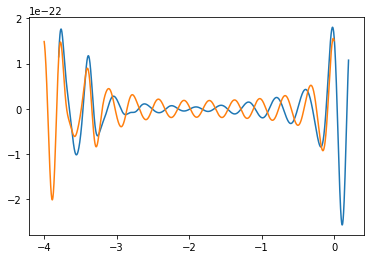

(19.98667418892256, 19.986674188922574)

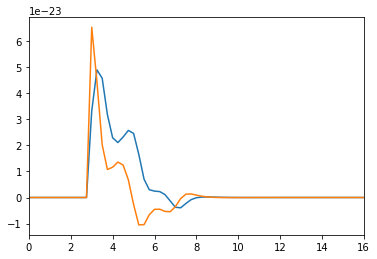

In [214]:
f_l = 3
hp, hc = get_td_waveform(inj, delta_t=delta_t, f_lower=f_l)
hp.plot()
t = hp.to_frequencyseries()
hp_tilde, hc_tilde = get_fd_waveform(inj, delta_f=hp.delta_f, f_lower=f_l, f_final=t.sample_frequencies.numpy()[-1])
hp2 = hp_tilde.to_timeseries()
hp2.plot()
show()
hp_tilde.plot()
xlim(0,16)
length = len(hp_tilde)
psd = EinsteinTelescopeP1600143(length, hp.delta_f, f_l)
sigma(hp, psd=psd, low_frequency_cutoff=f_l), sigma(hp_tilde, psd=psd, low_frequency_cutoff=f_l)

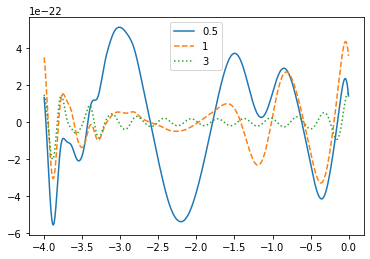

In [230]:
inj.approximant="IMRPhenomXHM"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp_tilde, hc_tilde = get_fd_waveform(inj, delta_f=hp.delta_f, f_lower=__fl, f_final=t.sample_frequencies.numpy()[-1])
    # hp_tilde.plot()
    hp = hp_tilde.to_timeseries()
    plot(hp.sample_times, hp, ls=ls, label=__fl)
legend()
# xlim(0,16)
# ylim(0, 3e-22)
# xlim()

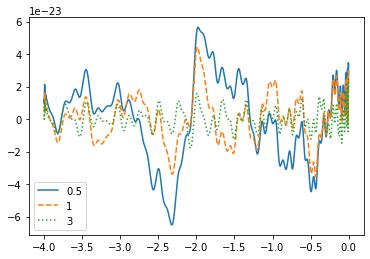

In [233]:
inj.approximant="IMRPhenomHM"
inj.mass1=100
inj.mass2=50
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp_tilde, hc_tilde = get_fd_waveform(inj, delta_f=hp.delta_f, f_lower=__fl, f_final=t.sample_frequencies.numpy()[-1])
    # hp_tilde.plot()
    hp = hp_tilde.to_timeseries()
    plot(hp.sample_times, hp, ls=ls, label=__fl)
legend()
# xlim(0,16)
# ylim(0, 3e-22)
# xlim()

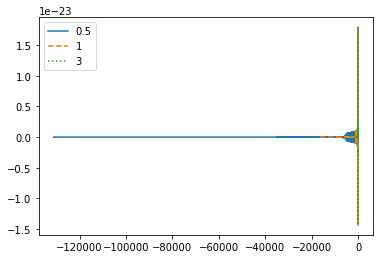

In [235]:
inj.approximant="IMRPhenomHM"
inj.mass1=100
inj.mass2=50
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp, hc = get_td_waveform(inj, delta_t=hp.delta_t, f_lower=__fl, f_final=t.sample_frequencies.numpy()[-1])
    plot(hp.sample_times, hp, ls=ls, label=__fl)
legend()
# xlim(0,16)
# ylim(0, 3e-22)
# xlim()

(0.0, 3e-22)

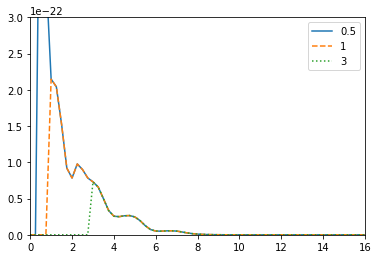

In [223]:
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp_tilde, hc_tilde = get_fd_waveform(inj, delta_f=hp.delta_f, f_lower=__fl, f_final=t.sample_frequencies.numpy()[-1])
    # hp_tilde.plot()
    plot(hp_tilde.sample_frequencies, abs(hp_tilde), ls=ls, label=__fl)
legend()
xlim(0,16)
ylim(0, 3e-22)
# xlim()

In [213]:
hp.sample_times[0]

-32767.8

(-1e-22, 1e-22)

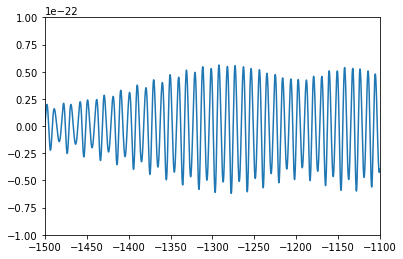

In [210]:
hp2.plot()
xlim(-1500, -1100)
ylim(-1e-22, 1e-22)

In [202]:
sigma(hp_tilde, psd=psd, low_frequency_cutoff=3)

19.638429224654626

In [204]:
sigma(hp, psd, low_frequency_cutoff=3)

19.638429224654676

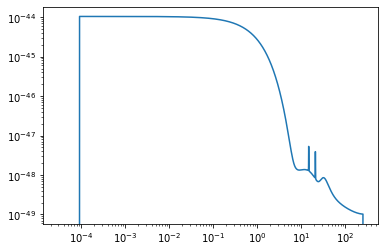

In [201]:
psd = EinsteinTelescopeP1600143(length, hp.delta_f, 0.0001)
loglog(psd.sample_frequencies, psd)

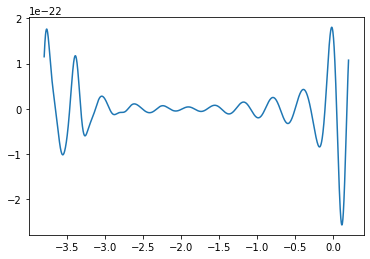